In [2]:
import cv2 as cv
import time
import torch
import numpy as np
import torch.nn as nn
import torchvision as tv
from torchvision import transforms
from torchvision.datasets import MNIST
import torch.optim as optim
import os
from torch.utils.data import DataLoader, Dataset
import pickle as pkl
from PIL import Image
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

random_seed = 42
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
np.random.seed(random_seed)
random.seed(random_seed)

In [3]:
path=os.getcwd()

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = tv.datasets.MNIST(root=path, train=True, transform=transform, download=True)
test_dataset = tv.datasets.MNIST(root=path, train=False, transform=transform, download=True)


train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)

In [5]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /home/hi_phi_rai
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [127]:
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN,self).__init__()
    
        self.flow=nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding=1),
            nn.BatchNorm2d(16,eps=5e-4),
            nn.LeakyReLU(),
            nn.Dropout(0.3),
            
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=5,padding=2),
            nn.BatchNorm2d(num_features=32,eps=5e-4),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            
            nn.MaxPool2d(2,2),
            nn.ReLU(),

            nn.Conv2d(in_channels=32,out_channels=16,kernel_size=3,padding=1),
            nn.BatchNorm2d(num_features=16),
            nn.LeakyReLU(),
            nn.Dropout(0.1),
        
            nn.AvgPool2d(2,2),
            nn.LeakyReLU(),

            nn.Flatten(),

            nn.Linear(784,120),
            nn.BatchNorm1d(num_features=120),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(120,48),
            nn.BatchNorm1d(48),
            nn.LeakyReLU(),
            nn.Dropout(0.14),
            
            nn.Linear(48,10)
        )
    def forward(self,x):
        x=self.flow(x)
        return x

In [128]:
model=myCNN()
model.to(device)
print(model)

myCNN(
  (flow): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=0.0005, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(32, eps=0.0005, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.2, inplace=False)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): ReLU()
    (10): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): LeakyReLU(negative_slope=0.01)
    (13): Dropout(p=0.1, inplace=False)
    (14): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (15): LeakyReLU(negative_slope=0.01)
    (16): Flatten(start_dim=1, end_dim=-

In [129]:
criterion = nn.CrossEntropyLoss() 
optimizer = optim.AdamW(model.parameters(),lr=0.001,weight_decay=5e-3)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.62,patience=3,min_lr=1e-5)

In [130]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    training_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()

        
    model.eval()
    val_loss=0.0
    with torch.no_grad():
        for(images,labels) in test_loader:
            images,labels=images.to(device), labels.to(device)
            out=model(images)
            l=criterion(out, labels)
            val_loss+=l.item()
        scheduler.step(val_loss/len(test_loader))
        

        
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {training_loss/len(train_loader):.4f}, Val Loss: {val_loss/len(test_loader)}, Current Lr:{scheduler.get_last_lr()}")
    

Epoch [1/50], Train Loss: 0.2795, Val Loss: 0.05663505677558199, Current Lr:[0.001]
Epoch [2/50], Train Loss: 0.0660, Val Loss: 0.04287489673971564, Current Lr:[0.001]
Epoch [3/50], Train Loss: 0.0520, Val Loss: 0.04193216444971629, Current Lr:[0.001]
Epoch [4/50], Train Loss: 0.0429, Val Loss: 0.027314526809945325, Current Lr:[0.001]
Epoch [5/50], Train Loss: 0.0382, Val Loss: 0.023698880200132822, Current Lr:[0.001]
Epoch [6/50], Train Loss: 0.0331, Val Loss: 0.023193342435833868, Current Lr:[0.001]
Epoch [7/50], Train Loss: 0.0308, Val Loss: 0.021643019680676487, Current Lr:[0.001]
Epoch [8/50], Train Loss: 0.0274, Val Loss: 0.02041854839801458, Current Lr:[0.001]
Epoch [9/50], Train Loss: 0.0264, Val Loss: 0.02211741583135946, Current Lr:[0.001]
Epoch [10/50], Train Loss: 0.0254, Val Loss: 0.018521821403380812, Current Lr:[0.001]
Epoch [11/50], Train Loss: 0.0235, Val Loss: 0.019618507535815757, Current Lr:[0.001]
Epoch [12/50], Train Loss: 0.0223, Val Loss: 0.0211297779887785, Cur

In [131]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total):.2f}%")


Test Accuracy: 99.53%


In [134]:
import torchvision.datasets as ds

In [138]:
list(ds)

TypeError: 'module' object is not iterable

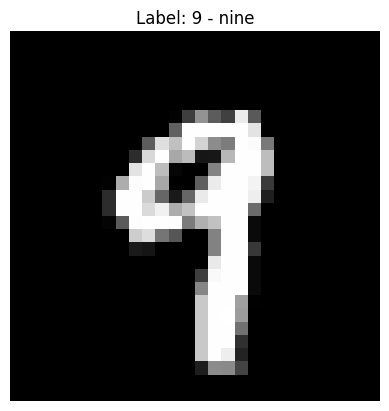

In [8]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))



plt.imshow(images[0][0][:][:], cmap="gray")
plt.subplot()
plt.title(f"Label: {train_dataset.classes[labels[0]]}")
plt.axis("off")
plt.show()


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import MeanSquarederror
from sklearn.model_selection import train_test_split

ImportError: cannot import name 'MeanSquaredError' from 'sklearn.metrics' (/home/hi_phi_rai/miniconda3/envs/ml/lib/python3.10/site-packages/sklearn/metrics/__init__.py)

In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)
preds=model.predict(X_valid)
loss=MSE(preds, y_valid)